PROJECT 01:
**Netflix** **Exploratory Data Analysis**

# Netflix Movies and TV Shows - Exploratory Data Analysis

## Objective
The objective of this project is to analyze the Netflix Movies and TV Shows dataset to identify patterns, trends, and insights related to content distribution, release years, countries, ratings, and genres.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [33]:
import os
print(os.getcwd())

/content


In [34]:
import os

for root, dirs, files in os.walk('/'):
    if 'netflix_titles.csv' in files:
        print(os.path.join(root, 'netflix_titles.csv'))
        break

/netflix_titles.csv


Step 1: Load and Inspect the Dataset

In [35]:
import pandas as pd

df = pd.read_csv('/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [36]:
df.shape


(8807, 12)

In [37]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [39]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Observation

The dataset contains 8807 rows and 12 columns. Each row represents a Netflix title, either a Movie or a TV Show.

Step 2: Data Cleaning


Missing Value Treatment


In [40]:
df.fillna('Not Available', inplace=True)

In [41]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Data Cleaning Result

After handling missing values, the dataset no longer contains any null values. All missing entries were replaced with "Not Available" to preserve the complete dataset and avoid information loss.

In [42]:
df.duplicated().sum()

np.int64(0)

Duplicate Record Analysis

The dataset was checked for duplicate records using the duplicated() function. No duplicate rows were found in the dataset; therefore, no records were removed.

Step 3: Exploratory Data Analysis

Question 1

**Which type of content is more common on Netflix: Movies or TV Shows?**

In [43]:
df['type'].value_counts()


,count
type,
Movie,6131
TV Show,2676


Since 6131 > 2676
Movies are significantly more common than TV Shows on Netflix

Visualization 1: Movies vs TV Shows Distribution



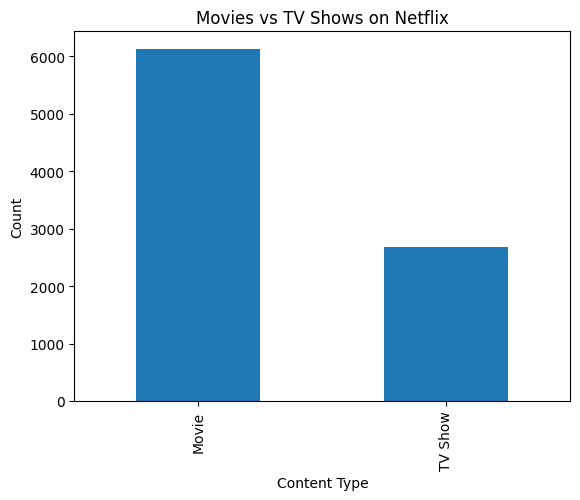

In [44]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

 Insight 1

Movies dominate Netflix's content library, accounting for more than twice the number of TV Shows.

Question 2

**Which countries contribute the most content to Netflix?**

In [45]:
country_counts = df[df['country'] != 'Not Available']['country'].value_counts().head(10)

country_counts


,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


Visualization 2: Top 10 Content Producing Countries


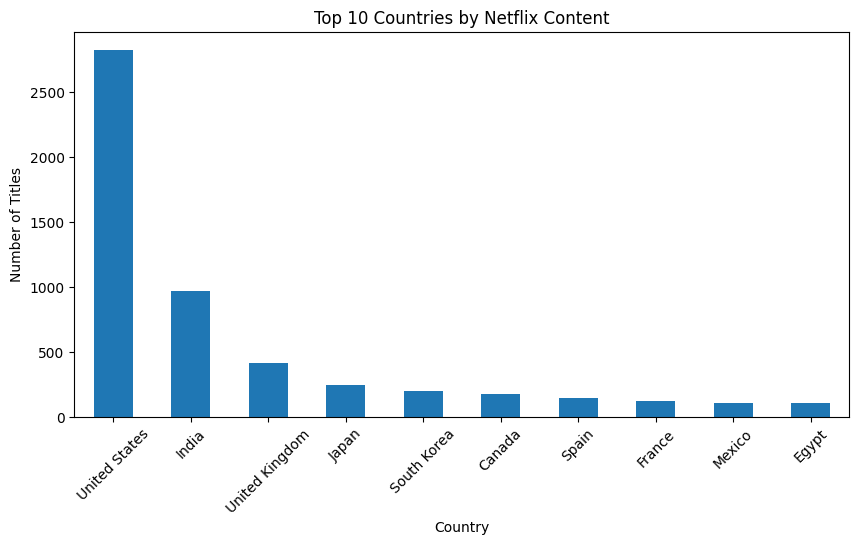

In [46]:
country_counts = df[df['country'] != 'Not Available']['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

country_counts.plot(kind='bar')

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

Insight 2

The United States is the dominant contributor to Netflix's content library, while India ranks second. This suggests that Netflix has a strong content presence in both Western and Asian markets.

Question 3

**How has Netflix content production changed over the years?**

In [47]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


Visualization 3

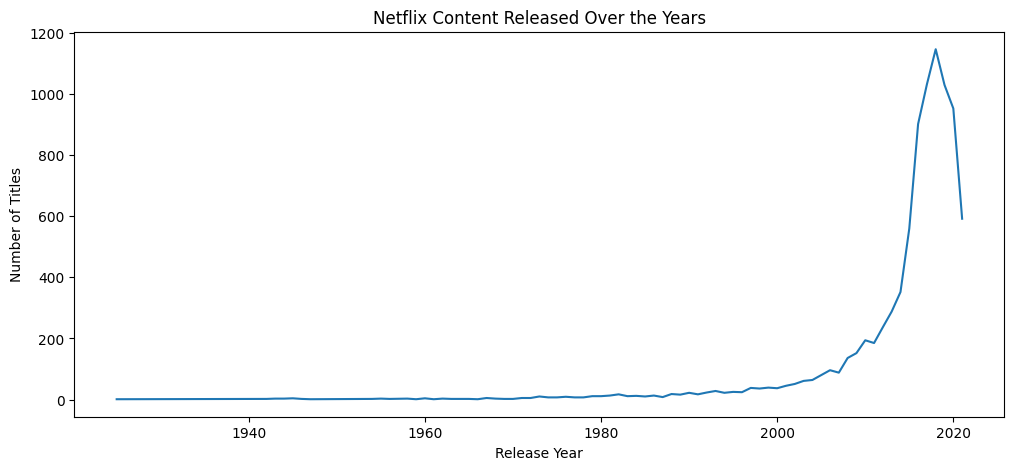

In [48]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.plot(kind='line')

plt.title('Netflix Content Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

Insight 3

Netflix experienced rapid growth in content releases between 2010 and 2018, demonstrating a significant expansion of its content library. The year 2018 recorded the highest number of titles in the dataset.

Question 4

**What are the most common content ratings on Netflix?**

In [49]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Visualization 4: Top Content Ratings on Netflix


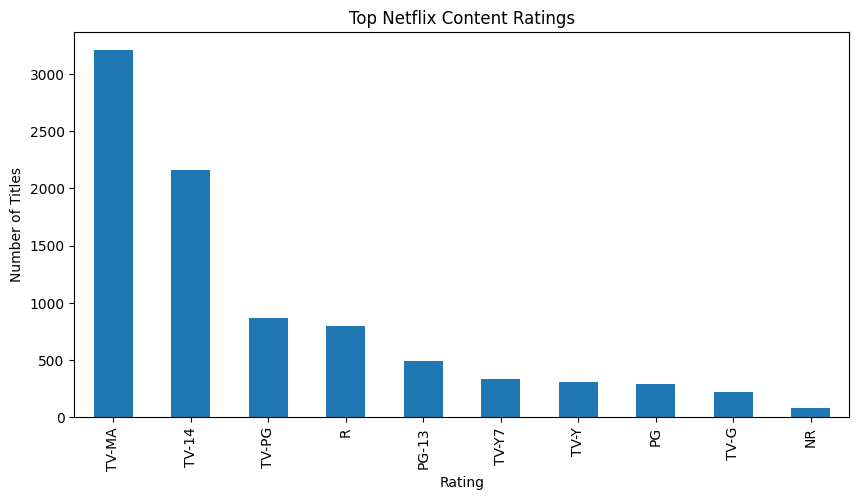

In [50]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar')

plt.title('Top Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.show()

Insight 4

Netflix primarily focuses on mature and teenage audiences, as TV-MA and TV-14 account for the largest share of content ratings on the platform.

Question 5

**Which genres are most popular on Netflix?**

In [51]:
df['listed_in'].value_counts()

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
...,...
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Music & Musicals",1
"Classic Movies, Horror Movies, Thrillers",1


In [52]:
genres = df['listed_in'].str.split(', ').explode()

genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [53]:
genres = df['listed_in'].str.split(', ').explode()

genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


Visualization 5: Top 10 Netflix Genres


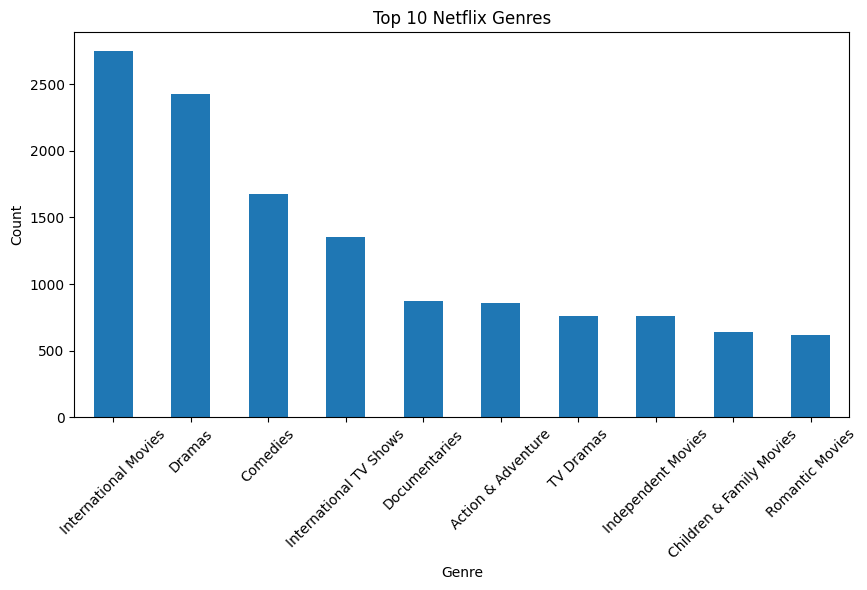

In [54]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

Insight 5

International Movies, Dramas, and Comedies dominate Netflix's content library, suggesting a strong emphasis on globally accessible entertainment and storytelling.

Visualization 6: Movies vs TV Shows Distribution

PIE CHART




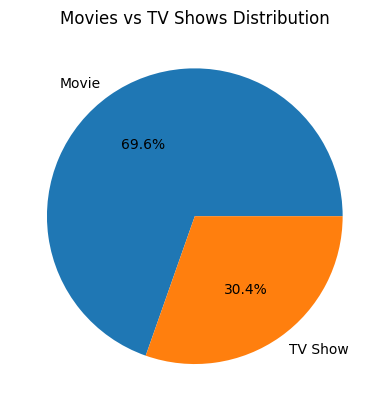

In [55]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')

plt.show()

Visualization 7: Distribution of Release Years

HISTOGRAM

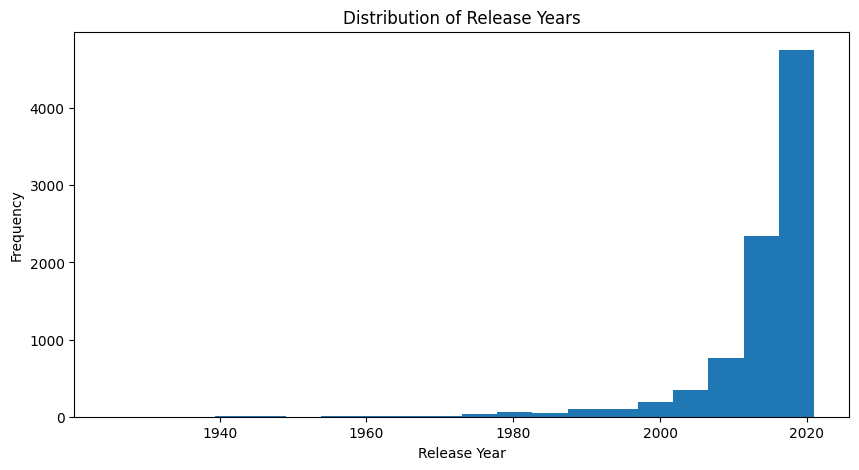

In [56]:
plt.figure(figsize=(10,5))

plt.hist(df['release_year'], bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

Observation

The histogram shows that most Netflix titles were released in recent years, particularly after 2010. Very few titles belong to earlier decades, indicating Netflix's strong focus on contemporary content.

Visualization 8: Release Year Distribution

SCATTER plot

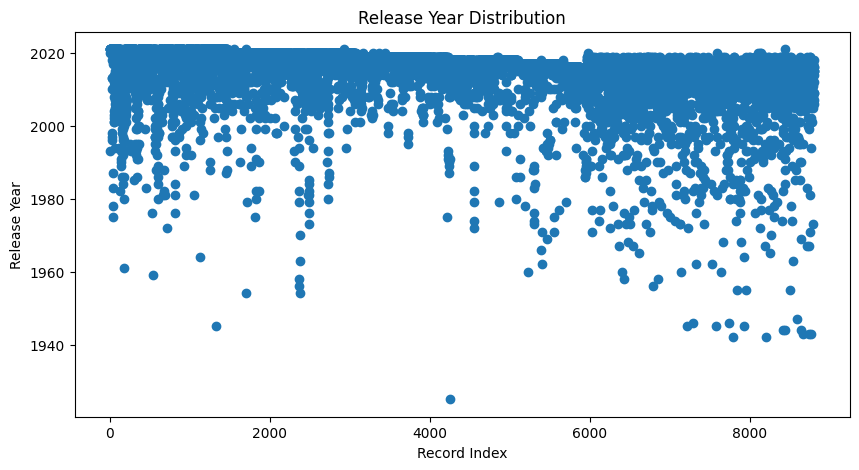

In [57]:
plt.figure(figsize=(10,5))

plt.scatter(df.index, df['release_year'])

plt.title('Release Year Distribution')
plt.xlabel('Record Index')
plt.ylabel('Release Year')

plt.show()

Observation

The scatter plot indicates that the majority of Netflix titles belong to recent years, while only a small number of titles originate from earlier decades. This supports the findings from the histogram analysis.

Visualization 9: Missing Values Heatmap



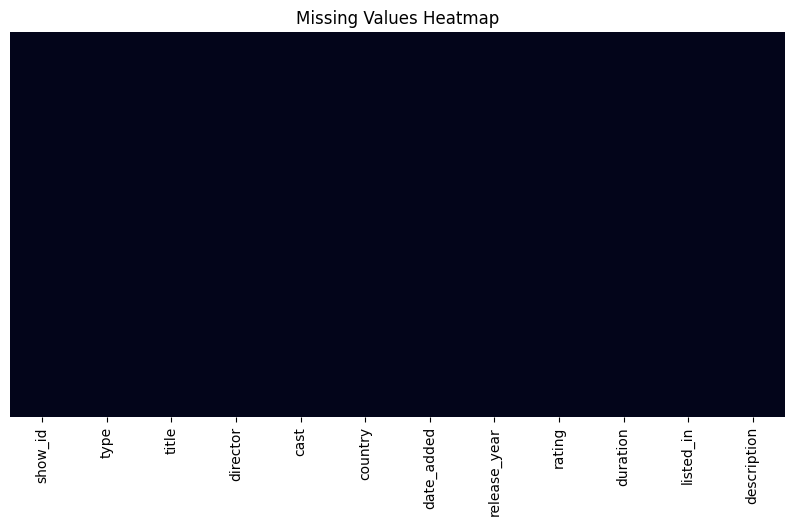

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False)

plt.title('Missing Values Heatmap')

plt.show()

Observation

The heatmap confirms that there are no remaining missing values in the dataset after the data cleaning process.

STEP 4: INSIGHTS REPORT

### **Insight 1**

Movies make up most of the content available on Netflix. Compared to TV Shows, there are significantly more movies on the platform.

### **Insight 2**

The United States contributes the highest number of titles on Netflix. India is the second-largest contributor, showing the importance of both countries in Netflix's content library.

### **Insight 3**

The number of titles released on Netflix increased rapidly after 2010 and reached its highest point in 2018. This shows how quickly Netflix expanded its content collection over the years.

### **Insight 4**

Most Netflix content is rated TV-MA and TV-14. This suggests that Netflix mainly focuses on content for teenagers and adults.

### **Insight 5**

International Movies, Dramas, and Comedies are among the most popular genres on Netflix. This shows that viewers enjoy a wide variety of entertainment from different countries and cultures.


# **MOST SURPRISING FINDING**

- The most surprising finding was the rapid growth in Netflix content after 2010.
- The number of titles increased significantly between 2015 and 2018.
- 2018 had the highest number of content releases in the dataset.
- This shows how quickly Netflix expanded its content library over a short period.
- The trend highlights Netflix's strong focus on increasing content for its growing audience.

# **CONCLUSION**

The Netflix dataset was successfully analyzed using data cleaning, visualization, and exploratory data analysis techniques.

The findings revealed key trends in content type, release years, ratings, countries, and genres.

 Overall, the analysis provided meaningful insights into Netflix's content library and audience focus.